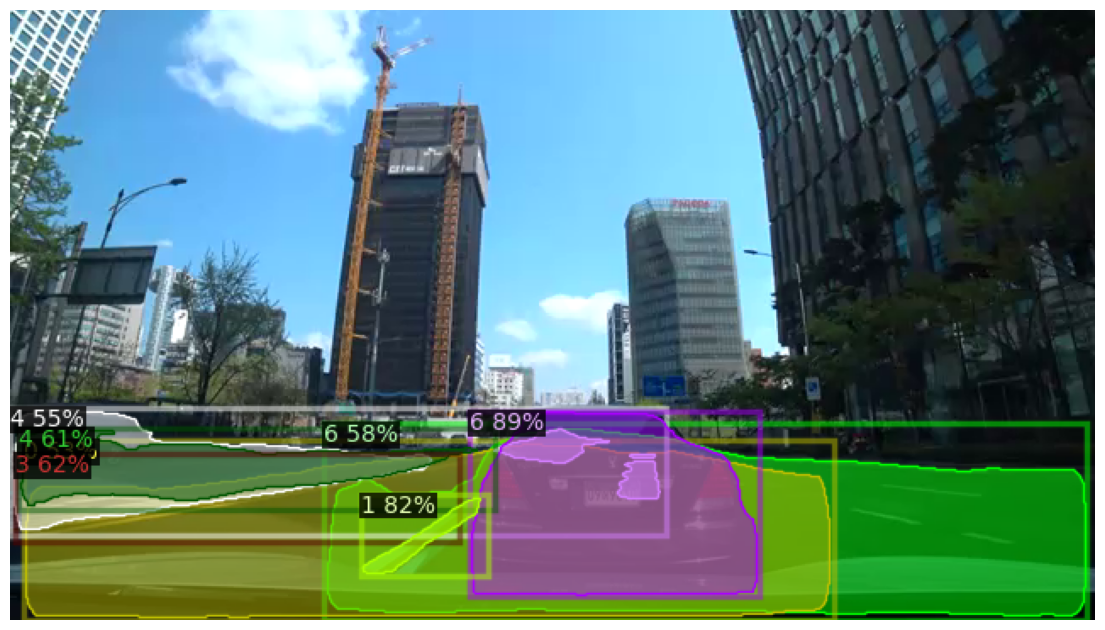

In [9]:
import cv2
import torch
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer, ColorMode
from detectron2.data import MetadataCatalog
import matplotlib.pyplot as plt

# ------------------------
# 1. 모델 설정
# ------------------------


cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
)
cfg.MODEL.ROI_HEADS.NUM_CLASSES = cat_len  # 사용자 클래스 수
cfg.MODEL.WEIGHTS = "/home/elicer/dev/jh/script/output/train_test/model_final.pth"
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = DefaultPredictor(cfg)

# 메타데이터 로드
try:
    metadata = MetadataCatalog.get("train_parking")
except:
    metadata = MetadataCatalog.get("__unused")  # fallback

# ------------------------
# 2. 영상 읽기 (첫 프레임만)
# ------------------------
cap = cv2.VideoCapture("/home/elicer/dev/jh/data/sample_video.mp4")
ret, frame = cap.read()
cap.release()

if not ret:
    raise ValueError("Error: cannot read video")

# OpenCV는 BGR, matplotlib는 RGB이므로 변환
frame_rgb = frame[:, :, ::-1]

# ------------------------
# 3. 단일 프레임 추론
# ------------------------
outputs = predictor(frame)

# ------------------------
# 4. 시각화
# ------------------------
v = Visualizer(
    frame_rgb,
    metadata=metadata,
    scale=1.0,
    instance_mode=ColorMode.IMAGE
)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

# Notebook에서 보기 좋게 출력
plt.figure(figsize=(14, 8))
plt.imshow(out.get_image())
plt.axis('off')
plt.show()


In [ ]:
import json

with open('/home/elicer/dev/jh/data/train_subset.json', 'r') as f:
    data = json.load(f)
    cat_len = (len(data.get('categories')))

print(cat_len)

29


In [ ]:
import os
import cv2
import torch
import json
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog


json_path = "/home/elicer/dev/jh/data/train_subset.json"

with open(json_path, "r") as f:
        data = json.load(f)
class_names = [c["name"] for c in data["categories"]]

cat_len = (len(data.get('categories')))

# Config 불러오기
cfg = get_cfg()
cfg.merge_from_file("./detectron2_repo/configs/COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.MODEL.WEIGHTS = os.path.join('./output/train_test', "/home/elicer/dev/jh/script/output/train_test/model_final.pth")  # 학습 완료 모델
cfg.MODEL.ROI_HEADS.NUM_CLASSES = cat_len  # 학습할 때 설정한 클래스 수
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # 추론 시 threshold
cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = DefaultPredictor(cfg)

metadata = MetadataCatalog.get("train_parking")
metadata.thing_classes = class_names

In [ ]:
import cv2
from detectron2.utils.visualizer import Visualizer

video_path = "/home/elicer/dev/jh/data/sample_video.mp4"
output_path = "output_video_bbox_label.mp4"
target_fps = 30

cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_fps = cap.get(cv2.CAP_PROP_FPS)

if video_fps <= 0:
    video_fps = target_fps

frame_interval = max(1, int(video_fps / target_fps))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, target_fps, (width, height))

frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    if frame_count % frame_interval == 0:
        outputs = predictor(frame)
        instances = outputs["instances"].to("cpu")

        # Visualizer
        v = Visualizer(frame[:, :, ::-1], metadata=metadata, scale=1.0)
        v = v.draw_instance_predictions(instances)
        result_frame = v.get_image()[:, :, ::-1]

        out.write(result_frame)

    frame_count += 1

cap.release()
out.release()
cv2.destroyAllWindows()
print("영상 추론 완료! 출력:", output_path)

영상 추론 완료! 출력: output_video_bbox_label.mp4


In [ ]:
# 30fps polygon only

import cv2
import torch
import numpy as np
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2.engine import DefaultPredictor
from detectron2.structures import Instances, Boxes, PolygonMasks

# ============================
# 설정
# ============================
video_path = "/home/elicer/dev/jh/data/sample_video.mp4"
output_path = "output_video_polygon.mp4"
target_fps = 30


# ============================
# 영상 읽기
# ============================
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
video_fps = cap.get(cv2.CAP_PROP_FPS)

if video_fps <= 0:
    video_fps = target_fps

frame_interval = max(1, int(video_fps / target_fps))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, target_fps, (width, height))

frame_count = 0

# ============================
# 영상 처리
# ============================
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # target_fps 기준으로 frame sampling
    if frame_count % frame_interval == 0:
        outputs = predictor(frame)
        instances = outputs["instances"].to("cpu")

        # mask → polygon 변환
        if instances.has("pred_masks"):
            masks = instances.pred_masks.numpy()  # (N, H, W)
            for mask in masks:
                # find contours
                mask_uint8 = mask.astype(np.uint8) * 255
                contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                # draw polygons
                cv2.polylines(frame, contours, isClosed=True, color=(0, 255, 0), thickness=2)

        # 출력
        out.write(frame)

    frame_count += 1

cap.release()
out.release()
cv2.destroyAllWindows()
print("영상 추론 완료! 출력:", output_path)

영상 추론 완료! 출력: output_video_polygon.mp4
